# Stage 1: OD + HE Removal (Blackout), CLAHE Enhancement & Konversi ke Format YOLO

**Pipeline:**
1. Load gambar fundus retina original
2. Load ground truth mask OD (Optic Disc) dan HE (Hard Exudate)
3. **Blackout** — set piksel di area OD & HE menjadi hitam `[0, 0, 0]`
4. **CLAHE pada Green Channel** — enhance kontras soft exudate yang halus
   - Referensi: Maqsood et al. (2022), Patil et al. (2020), IIETA (2024)
   - Parameter: clip limit = 2.0, tile grid = 8×8 (standar di literatur DR)
5. Konversi mask SE (Soft Exudate) ke format poligon YOLO
6. Simpan dataset dalam struktur folder YOLO

## 1. Import & Konfigurasi Path

In [12]:
import cv2
import numpy as np
import shutil
import yaml
import matplotlib.pyplot as plt
from pathlib import Path

# === Path Dataset ===
BASE_DIR = Path(".")

ORIG_TRAIN = BASE_DIR / "1. Original Images" / "a. Training Set"
ORIG_VAL   = BASE_DIR / "1. Original Images" / "b. Testing Set"

GT_BASE_TRAIN = BASE_DIR / "2. All Segmentation Groundtruths" / "a. Training Set"
GT_BASE_VAL   = BASE_DIR / "2. All Segmentation Groundtruths" / "b. Testing Set"

GT_SE_TRAIN = GT_BASE_TRAIN / "4. Soft Exudates"
GT_OD_TRAIN = GT_BASE_TRAIN / "5. Optic Disc"
GT_HE_TRAIN = GT_BASE_TRAIN / "3. Hard Exudates"

GT_SE_VAL = GT_BASE_VAL / "4. Soft Exudates"
GT_OD_VAL = GT_BASE_VAL / "5. Optic Disc"
GT_HE_VAL = GT_BASE_VAL / "3. Hard Exudates"

OUTPUT_DIR = Path("yolo_dataset")

CLASS_SE = 0  # Hanya 1 class: soft_exudate

print("Path konfigurasi OK")

Path konfigurasi OK


## 2. Helper Functions

In [13]:
def load_binary_mask(tif_path):
    """
    Load file TIF ground truth IDRiD -> binary mask.
    IDRiD ground truth: piksel non-zero = area lesi.
    Return: numpy array [H, W] uint8, nilai 0 atau 255.
    """
    img = cv2.imread(str(tif_path), cv2.IMREAD_UNCHANGED)
    if img is None:
        return None

    # Jika multi-channel (RGB/RGBA), ambil max dari RGB
    if img.ndim == 3:
        img = img[:, :, :3].max(axis=2)

    # Binarisasi: piksel > 10 -> 255
    binary_mask = np.where(img > 10, 255, 0).astype(np.uint8)
    return binary_mask


def apply_blackout(image_bgr, od_mask, he_mask):
    """
    Hapus OD dan HE dari gambar dengan metode BLACKOUT.
    Set piksel di area OD/HE menjadi hitam [0, 0, 0].
    """
    result = image_bgr.copy()

    if od_mask is not None:
        result[od_mask > 0] = 0
    if he_mask is not None:
        result[he_mask > 0] = 0

    return result


def apply_clahe(image_bgr, clip_limit=2.0, tile_grid_size=(8, 8)):
    """
    Apply CLAHE pada green channel untuk meningkatkan kontras soft exudate.

    Green channel dipilih karena memberikan kontras terbaik terhadap
    struktur retina dan lesi (Maqsood et al. 2022, Patil et al. 2020).

    Parameter standar dari literatur:
    - clip_limit = 2.0 (Setiawan et al. 2013, Welfer et al. 2013)
    - tile_grid_size = 8x8 (konsensus mayoritas paper DR)
    """
    # Split channel BGR
    b, g, r = cv2.split(image_bgr)

    # Apply CLAHE hanya pada green channel
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    g_enhanced = clahe.apply(g)

    # Merge kembali
    result = cv2.merge([b, g_enhanced, r])
    return result


def mask_to_yolo_polygons(binary_mask, img_w, img_h, min_area=50):
    """
    Konversi binary mask -> list poligon format YOLO.
    Satu mask bisa punya banyak blob (tiap blob = 1 instance).
    """
    lines = []

    contours, _ = cv2.findContours(
        binary_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for contour in contours:
        area = cv2.contourArea(contour)
        if area < min_area:
            continue

        epsilon = 0.002 * cv2.arcLength(contour, closed=True)
        simplified = cv2.approxPolyDP(contour, epsilon, closed=True)

        if len(simplified) < 3:
            continue

        points = simplified.reshape(-1, 2).astype(float)
        points[:, 0] /= img_w
        points[:, 1] /= img_h
        points = np.clip(points, 0.0, 1.0)

        coords_str = " ".join([f"{x:.6f} {y:.6f}" for x, y in points])
        line = f"{CLASS_SE} {coords_str}"
        lines.append(line)

    return lines

print("Helper functions OK (termasuk CLAHE)")

Helper functions OK (termasuk CLAHE)


## 3. Proses Satu Split (Train / Val)

Fungsi utama yang memproses setiap split:
1. Load gambar original
2. Load mask OD (`_OD.tif`) dan HE (`_EX.tif`) — **perhatikan: IDRiD pakai suffix `_EX`, bukan `_HE`**
3. Blackout area OD & HE
4. **CLAHE pada green channel** (clip_limit=2.0, tile=8×8)
5. Konversi mask SE ke label YOLO
6. Simpan gambar + label

In [14]:
def process_split(orig_dir, gt_se_dir, gt_od_dir, gt_he_dir,
                  out_img_dir, out_lbl_dir, split_name):
    """Proses satu split: blackout OD+HE, CLAHE green channel, konversi SE mask ke YOLO."""
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)

    orig_files = sorted(
        f for f in Path(orig_dir).glob("*.jpg") if f.stem.startswith("IDRiD")
    )
    if not orig_files:
        orig_files = sorted(
            f for f in Path(orig_dir).glob("*.JPG") if f.stem.startswith("IDRiD")
        )

    print(f"\n[{split_name}] {len(orig_files)} gambar ditemukan")

    stats = {"total": len(orig_files), "with_se": 0, "without_se": 0,
             "total_instances": 0, "od_removed": 0, "he_removed": 0}

    for orig_path in orig_files:
        stem = orig_path.stem

        image_bgr = cv2.imread(str(orig_path))
        if image_bgr is None:
            print(f"  [SKIP] Tidak bisa load: {orig_path.name}")
            continue

        img_h, img_w = image_bgr.shape[:2]

        # Load ground truth masks
        # PENTING: Hard Exudate di IDRiD pakai suffix _EX, bukan _HE
        se_path = Path(gt_se_dir) / f"{stem}_SE.tif"
        od_path = Path(gt_od_dir) / f"{stem}_OD.tif"
        he_path = Path(gt_he_dir) / f"{stem}_EX.tif"

        se_mask = load_binary_mask(se_path) if se_path.exists() else None
        od_mask = load_binary_mask(od_path) if od_path.exists() else None
        he_mask = load_binary_mask(he_path) if he_path.exists() else None

        if od_mask is not None:
            stats["od_removed"] += 1
        if he_mask is not None:
            stats["he_removed"] += 1

        # Step 1: BLACKOUT area OD dan HE
        clean_image = apply_blackout(image_bgr, od_mask, he_mask)

        # Step 2: CLAHE pada green channel
        enhanced_image = apply_clahe(clean_image, clip_limit=2.0, tile_grid_size=(8, 8))

        # Simpan gambar hasil blackout + CLAHE
        out_img_path = out_img_dir / f"{stem}.jpg"
        cv2.imwrite(str(out_img_path), enhanced_image,
                    [cv2.IMWRITE_JPEG_QUALITY, 95])

        # Konversi SE mask ke label YOLO
        out_lbl_path = out_lbl_dir / f"{stem}.txt"

        if se_mask is not None and se_mask.sum() > 0:
            yolo_lines = mask_to_yolo_polygons(se_mask, img_w, img_h)

            if yolo_lines:
                with open(out_lbl_path, "w") as f:
                    f.write("\n".join(yolo_lines))
                stats["with_se"] += 1
                stats["total_instances"] += len(yolo_lines)
                print(f"  {stem}.jpg -> {len(yolo_lines)} instance SE"
                      f"  |  OD: {'v' if od_mask is not None else '-'}"
                      f"  HE: {'v' if he_mask is not None else '-'}")
            else:
                out_lbl_path.touch()
                stats["without_se"] += 1
        else:
            out_lbl_path.touch()
            stats["without_se"] += 1

    print(f"\n[{split_name}] Ringkasan:")
    print(f"  Total gambar        : {stats['total']}")
    print(f"  Gambar dengan SE    : {stats['with_se']}")
    print(f"  Gambar tanpa SE     : {stats['without_se']}")
    print(f"  Total instance SE   : {stats['total_instances']}")
    print(f"  OD di-blackout      : {stats['od_removed']} gambar")
    print(f"  HE di-blackout      : {stats['he_removed']} gambar")
    if stats["with_se"] > 0:
        avg = stats["total_instances"] / stats["with_se"]
        print(f"  Rata-rata SE/gambar : {avg:.1f}")

    return stats

print("process_split OK")

process_split OK


## 4. Jalankan Konversi

In [15]:
# Hapus output lama jika ada
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
    print(f"Folder lama '{OUTPUT_DIR}' dihapus")

# Struktur folder output
out_img_train = OUTPUT_DIR / "images" / "train"
out_img_val   = OUTPUT_DIR / "images" / "val"
out_lbl_train = OUTPUT_DIR / "labels" / "train"
out_lbl_val   = OUTPUT_DIR / "labels" / "val"

# === Proses TRAINING SET ===
print("=" * 50)
print("PROSES TRAINING SET")
print("=" * 50)
train_stats = process_split(
    orig_dir    = ORIG_TRAIN,
    gt_se_dir   = GT_SE_TRAIN,
    gt_od_dir   = GT_OD_TRAIN,
    gt_he_dir   = GT_HE_TRAIN,
    out_img_dir = out_img_train,
    out_lbl_dir = out_lbl_train,
    split_name  = "TRAIN",
)

# === Proses VALIDATION SET ===
print("\n" + "=" * 50)
print("PROSES VALIDATION SET")
print("=" * 50)
val_stats = process_split(
    orig_dir    = ORIG_VAL,
    gt_se_dir   = GT_SE_VAL,
    gt_od_dir   = GT_OD_VAL,
    gt_he_dir   = GT_HE_VAL,
    out_img_dir = out_img_val,
    out_lbl_dir = out_lbl_val,
    split_name  = "VAL",
)

Folder lama 'yolo_dataset' dihapus
PROSES TRAINING SET

[TRAIN] 54 gambar ditemukan
  IDRiD_03.jpg -> 1 instance SE  |  OD: v  HE: -
  IDRiD_08.jpg -> 3 instance SE  |  OD: v  HE: -
  IDRiD_13.jpg -> 8 instance SE  |  OD: v  HE: v
  IDRiD_14.jpg -> 1 instance SE  |  OD: v  HE: v
  IDRiD_17.jpg -> 7 instance SE  |  OD: v  HE: v
  IDRiD_18.jpg -> 3 instance SE  |  OD: v  HE: v
  IDRiD_19.jpg -> 9 instance SE  |  OD: v  HE: v
  IDRiD_22.jpg -> 6 instance SE  |  OD: v  HE: v
  IDRiD_23.jpg -> 5 instance SE  |  OD: v  HE: v
  IDRiD_25.jpg -> 4 instance SE  |  OD: v  HE: v
  IDRiD_30.jpg -> 2 instance SE  |  OD: v  HE: v
  IDRiD_31.jpg -> 8 instance SE  |  OD: v  HE: v
  IDRiD_32.jpg -> 6 instance SE  |  OD: v  HE: v
  IDRiD_33.jpg -> 1 instance SE  |  OD: v  HE: v
  IDRiD_35.jpg -> 3 instance SE  |  OD: v  HE: v
  IDRiD_38.jpg -> 2 instance SE  |  OD: v  HE: v
  IDRiD_39.jpg -> 10 instance SE  |  OD: v  HE: v
  IDRiD_46.jpg -> 6 instance SE  |  OD: v  HE: v
  IDRiD_47.jpg -> 1 instance SE  

## 5. Buat data.yaml

In [16]:
yaml_content = {
    "path"  : str(OUTPUT_DIR.resolve()),
    "train" : "images/train",
    "val"   : "images/val",
    "nc"    : 1,
    "names" : ["soft_exudate"],
}

yaml_path = OUTPUT_DIR / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)

print(f"data.yaml dibuat: {yaml_path}")
for k, v in yaml_content.items():
    print(f"  {k}: {v}")

data.yaml dibuat: yolo_dataset/data.yaml
  path: /Users/mac/Documents/Kuliah/Semester 6/Skripsi/yolo_dataset
  train: images/train
  val: images/val
  nc: 1
  names: ['soft_exudate']


## 6. Verifikasi Output

In [17]:
for split in ["train", "val"]:
    img_dir = OUTPUT_DIR / "images" / split
    lbl_dir = OUTPUT_DIR / "labels" / split

    imgs   = sorted(img_dir.glob("*.jpg"))
    labels = sorted(lbl_dir.glob("*.txt"))
    non_empty = [l for l in labels if l.stat().st_size > 0]

    img_stems = {f.stem for f in imgs}
    lbl_stems = {f.stem for f in labels}
    missing = img_stems - lbl_stems

    print(f"[{split}]")
    print(f"  Gambar: {len(imgs)}, Label: {len(labels)}, Label non-kosong: {len(non_empty)}")
    if missing:
        print(f"  MASALAH - Gambar tanpa label: {missing}")
    else:
        print(f"  OK - Semua gambar punya label")

    if non_empty:
        with open(non_empty[0]) as f:
            lines = f.readlines()
        print(f"  Contoh ({non_empty[0].name}): {len(lines)} instance")
        tokens = lines[0].strip().split()
        print(f"    class={tokens[0]}, {(len(tokens)-1)//2} titik poligon")
    print()

[train]
  Gambar: 54, Label: 54, Label non-kosong: 26
  OK - Semua gambar punya label
  Contoh (IDRiD_03.txt): 1 instance
    class=0, 52 titik poligon

[val]
  Gambar: 27, Label: 27, Label non-kosong: 14
  OK - Semua gambar punya label
  Contoh (IDRiD_55.txt): 2 instance
    class=0, 55 titik poligon



## 7. Visualisasi Hasil Preprocessing

Bandingkan: Original → Setelah Blackout OD+HE → Setelah Blackout + CLAHE

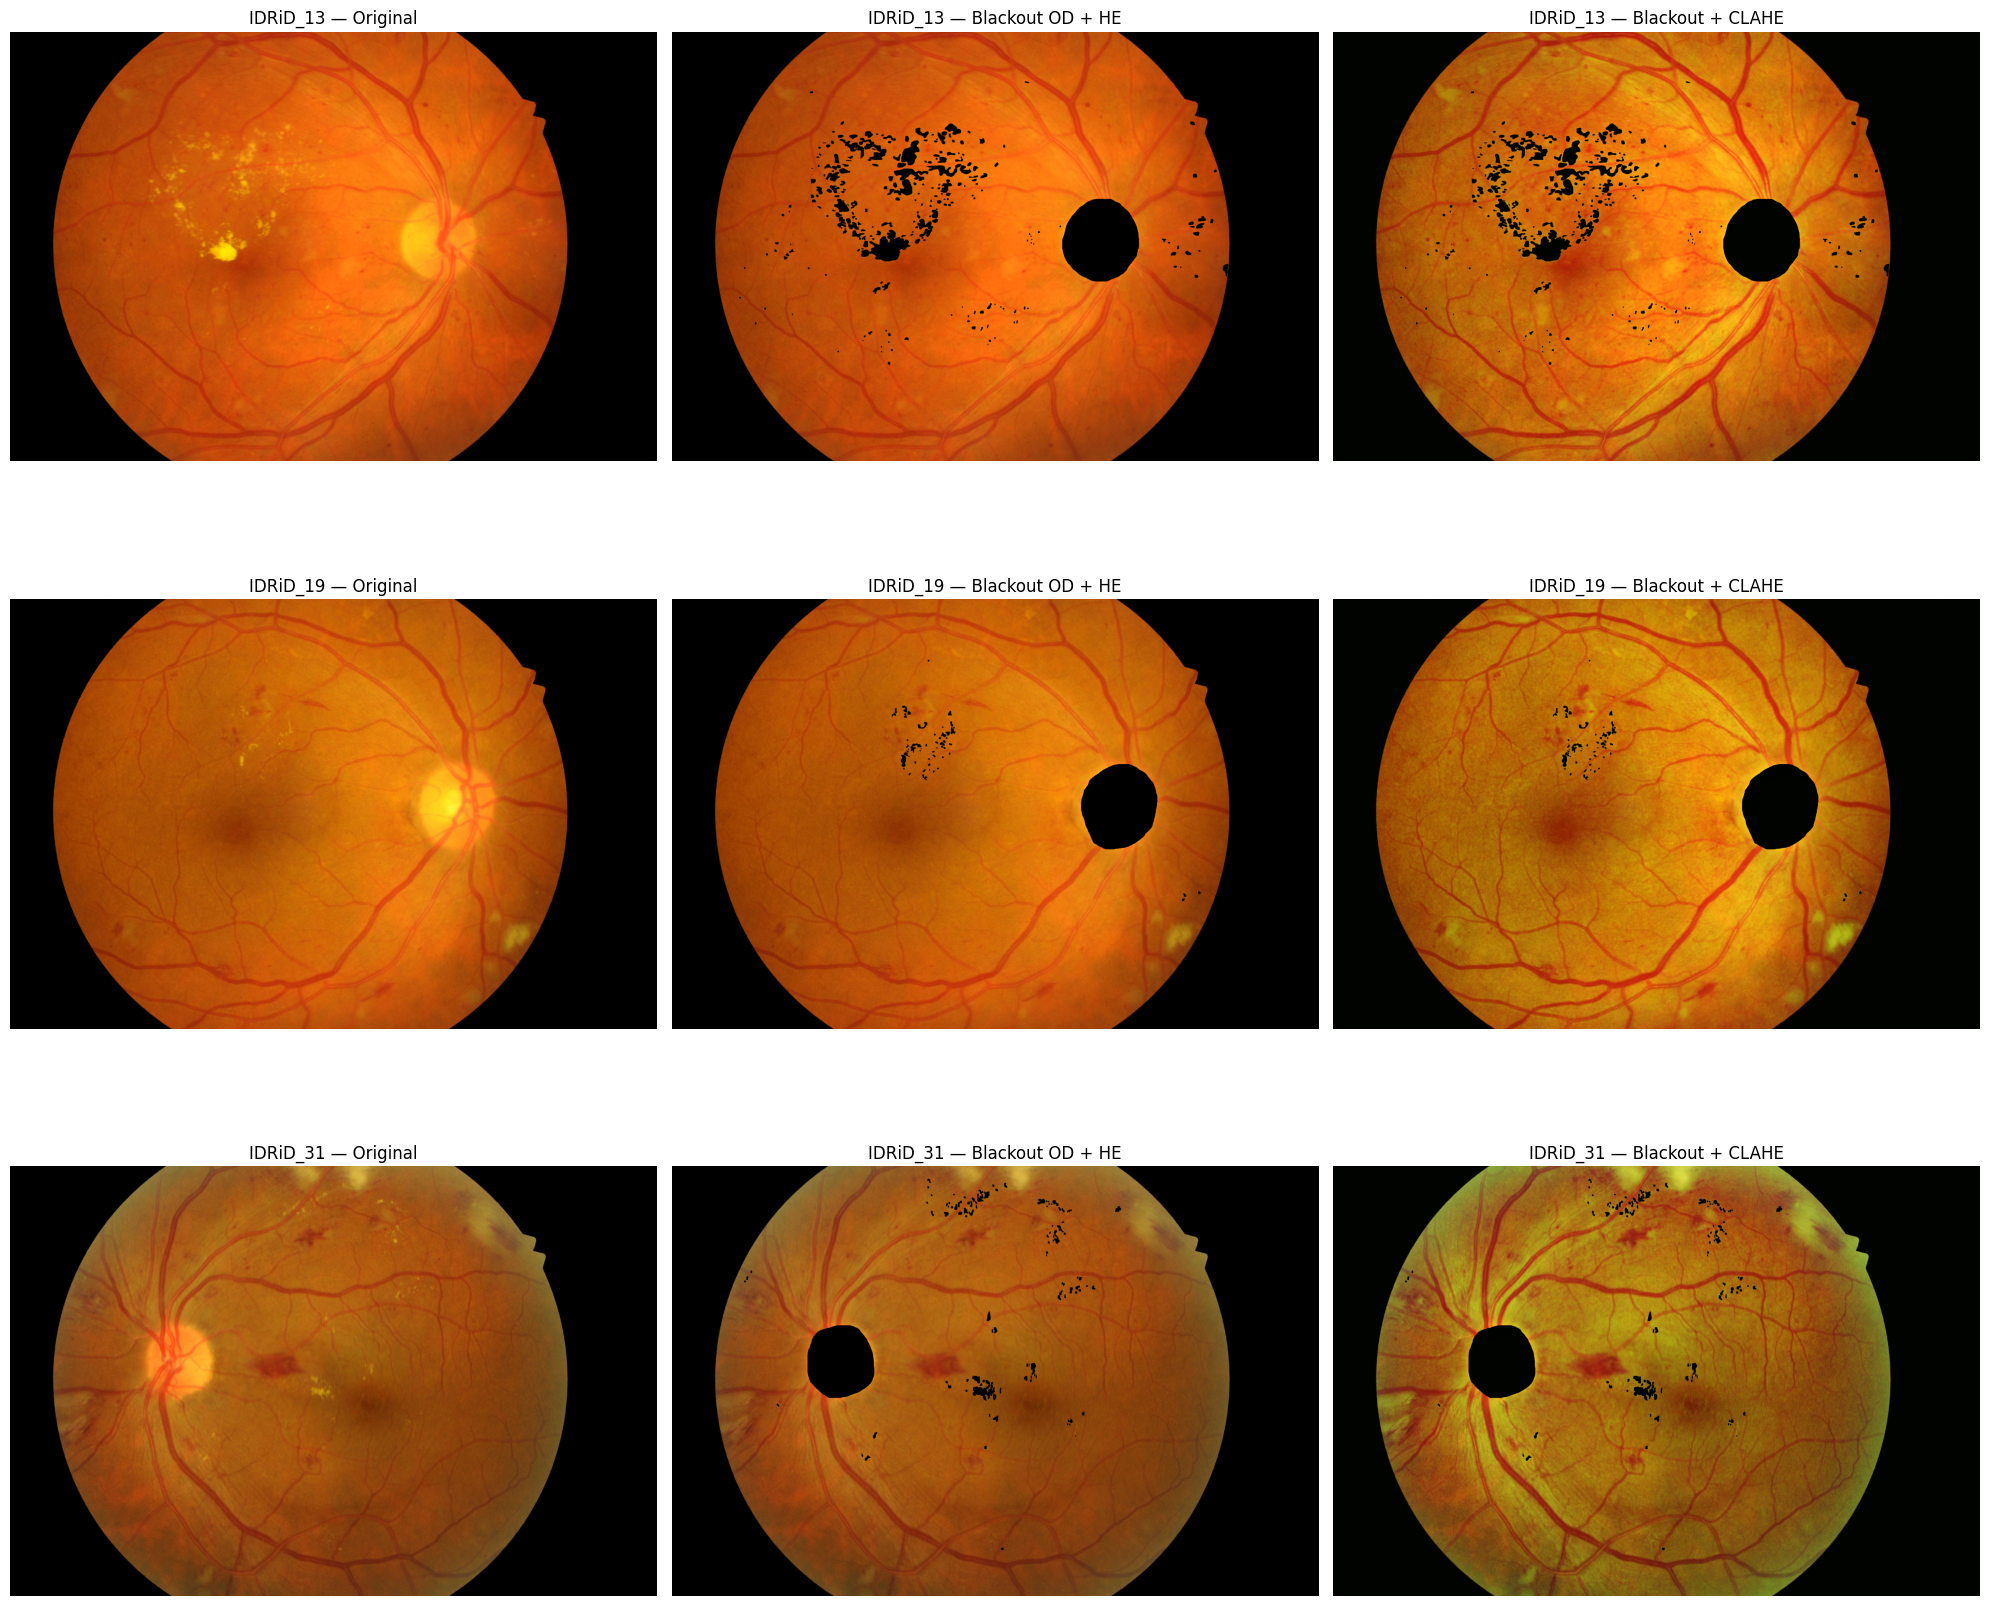

Visualisasi disimpan ke visualisasi_preprocessing.png


In [18]:
sample_stems = ["IDRiD_13", "IDRiD_19", "IDRiD_31"]

fig, axes = plt.subplots(len(sample_stems), 3, figsize=(20, 6 * len(sample_stems)))

for i, stem in enumerate(sample_stems):
    orig_path  = ORIG_TRAIN / f"{stem}.jpg"
    clean_path = OUTPUT_DIR / "images" / "train" / f"{stem}.jpg"

    if not orig_path.exists() or not clean_path.exists():
        print(f"Skip {stem} — file tidak ditemukan")
        continue

    orig_bgr  = cv2.imread(str(orig_path))
    clean_bgr = cv2.imread(str(clean_path))

    # Buat versi blackout-only (tanpa CLAHE) untuk perbandingan
    od_path = GT_OD_TRAIN / f"{stem}_OD.tif"
    he_path = GT_HE_TRAIN / f"{stem}_EX.tif"
    od_mask = load_binary_mask(od_path) if od_path.exists() else None
    he_mask = load_binary_mask(he_path) if he_path.exists() else None
    blackout_only = apply_blackout(orig_bgr, od_mask, he_mask)

    # Kolom 1: Original
    axes[i, 0].imshow(cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"{stem} — Original")
    axes[i, 0].axis("off")

    # Kolom 2: Blackout only
    axes[i, 1].imshow(cv2.cvtColor(blackout_only, cv2.COLOR_BGR2RGB))
    axes[i, 1].set_title(f"{stem} — Blackout OD + HE")
    axes[i, 1].axis("off")

    # Kolom 3: Blackout + CLAHE (gambar final yang disimpan)
    axes[i, 2].imshow(cv2.cvtColor(clean_bgr, cv2.COLOR_BGR2RGB))
    axes[i, 2].set_title(f"{stem} — Blackout + CLAHE")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("visualisasi_preprocessing.png", dpi=100, bbox_inches="tight")
plt.show()
print("Visualisasi disimpan ke visualisasi_preprocessing.png")

## 8. Investigasi: Cek Mask HE untuk IDRiD_13

Lihat apa isi raw mask HE dan bagaimana threshold mempengaruhi hasilnya.

=== IDRiD_13 HE Mask ===
  Shape: (2848, 4288), dtype: uint8
  Unique pixel values: [ 0 76]
  Piksel > 0 : 214,397
  Piksel > 10: 214,397
  Piksel > 50: 214,397
  Piksel > 100: 0

=== IDRiD_13 OD Mask ===
  Shape: (2848, 4288), dtype: uint8
  Piksel > 0: 216,047


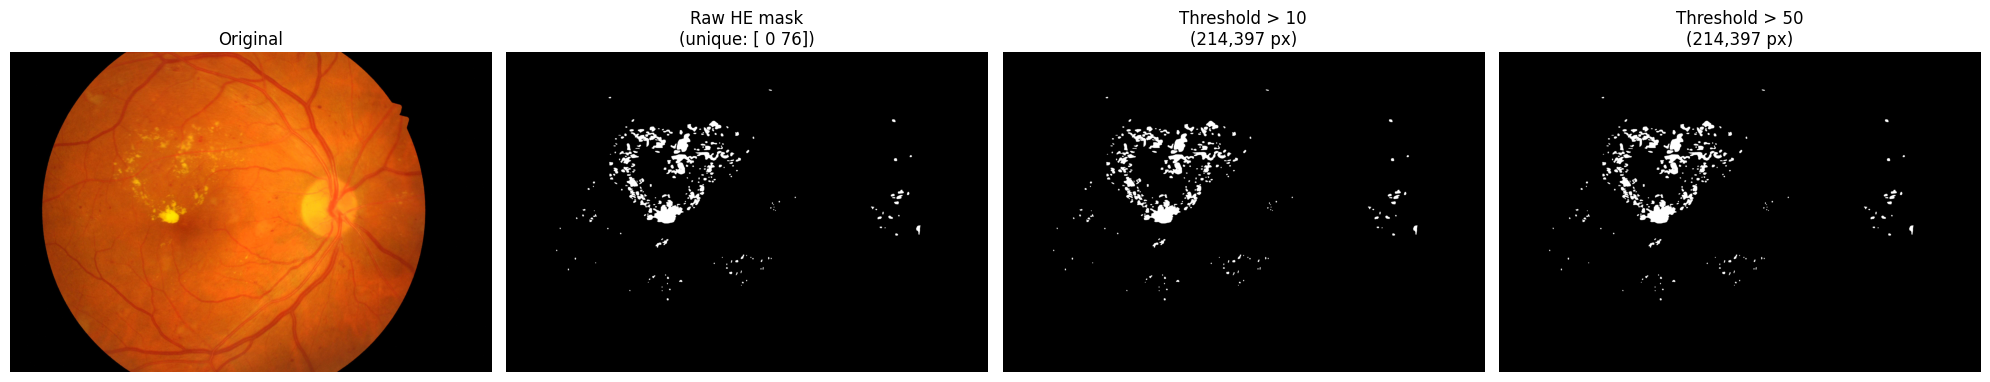

In [19]:
stem = "IDRiD_13"

# Load raw masks
he_raw = cv2.imread(str(GT_HE_TRAIN / f"{stem}_EX.tif"), cv2.IMREAD_UNCHANGED)
od_raw = cv2.imread(str(GT_OD_TRAIN / f"{stem}_OD.tif"), cv2.IMREAD_UNCHANGED)

print(f"=== {stem} HE Mask ===")
if he_raw is not None:
    print(f"  Shape: {he_raw.shape}, dtype: {he_raw.dtype}")
    if he_raw.ndim == 3:
        gray_he = he_raw[:, :, :3].max(axis=2)
    else:
        gray_he = he_raw
    unique_vals = np.unique(gray_he)
    print(f"  Unique pixel values: {unique_vals}")
    print(f"  Piksel > 0 : {(gray_he > 0).sum():,}")
    print(f"  Piksel > 10: {(gray_he > 10).sum():,}")
    print(f"  Piksel > 50: {(gray_he > 50).sum():,}")
    print(f"  Piksel > 100: {(gray_he > 100).sum():,}")
else:
    print("  TIDAK DITEMUKAN")

print(f"\n=== {stem} OD Mask ===")
if od_raw is not None:
    print(f"  Shape: {od_raw.shape}, dtype: {od_raw.dtype}")
    if od_raw.ndim == 3:
        gray_od = od_raw[:, :, :3].max(axis=2)
    else:
        gray_od = od_raw
    print(f"  Piksel > 0: {(gray_od > 0).sum():,}")
else:
    print("  TIDAK DITEMUKAN")

# Visualisasi mask HE dengan berbagai threshold
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(cv2.cvtColor(cv2.imread(str(ORIG_TRAIN / f"{stem}.jpg")), cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

if he_raw is not None:
    axes[1].imshow(gray_he, cmap="gray")
    axes[1].set_title(f"Raw HE mask\n(unique: {unique_vals})")
    axes[1].axis("off")

    axes[2].imshow((gray_he > 10).astype(np.uint8) * 255, cmap="gray")
    axes[2].set_title(f"Threshold > 10\n({(gray_he > 10).sum():,} px)")
    axes[2].axis("off")

    axes[3].imshow((gray_he > 50).astype(np.uint8) * 255, cmap="gray")
    axes[3].set_title(f"Threshold > 50\n({(gray_he > 50).sum():,} px)")
    axes[3].axis("off")

plt.tight_layout()
plt.show()

In [20]:
import cv2
import numpy as np
from pathlib import Path

for stem in ['IDRiD_13', 'IDRiD_19', 'IDRiD_03']:
    # Load semua mask
    he = cv2.imread(f"2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates/{stem}_HE.tif", 0)
    od = cv2.imread(f"2. All Segmentation Groundtruths/a. Training Set/5. Optic Disc/{stem}_OD.tif", 0)
    se = cv2.imread(f"2. All Segmentation Groundtruths/a. Training Set/4. Soft Exudates/{stem}_SE.tif", 0)
    
    total = 4288 * 2848
    
    he_pct = (he > 10).sum() / total * 100 if he is not None else 0
    od_pct = (od > 10).sum() / total * 100 if od is not None else 0
    se_pct = (se > 10).sum() / total * 100 if se is not None else 0
    
    # Yang paling penting: apakah HE overlap dengan SE?
    if he is not None and se is not None:
        he_bin = (he > 10).astype(np.uint8)
        se_bin = (se > 10).astype(np.uint8)
        overlap = cv2.bitwise_and(he_bin, se_bin).sum()
        print(f"{stem}: HE={he_pct:.2f}%, OD={od_pct:.2f}%, SE={se_pct:.2f}%, HE∩SE overlap={overlap} piksel")
    else:
        print(f"{stem}: HE={he_pct:.2f}%, OD={od_pct:.2f}%, SE={se_pct:.2f}%, (no SE gt)")

IDRiD_13: HE=0.00%, OD=1.77%, SE=0.58%, (no SE gt)
IDRiD_19: HE=0.00%, OD=1.83%, SE=0.67%, (no SE gt)
IDRiD_03: HE=0.00%, OD=1.96%, SE=0.03%, (no SE gt)


[ WARN:0@14557.890] global loadsave.cpp:278 findDecoder imread_('2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates/IDRiD_13_HE.tif'): can't open/read file: check file path/integrity
[ WARN:0@14557.919] global loadsave.cpp:278 findDecoder imread_('2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates/IDRiD_19_HE.tif'): can't open/read file: check file path/integrity
[ WARN:0@14557.946] global loadsave.cpp:278 findDecoder imread_('2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates/IDRiD_03_HE.tif'): can't open/read file: check file path/integrity
